# Multilayer perceptron

Pytorch framework documentation [here](https://pytorch.org/)

In [ ]:
#El entorno de ejecucion se cambia a CPU porque Keras no se ejecutara correctamente y el nombre de la libreria cambio a keras.utils
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import time
from tqdm import tqdm
from keras.utils import to_categorical

import torch
import torch.nn as nn

## Load data - [MNIST](http://yann.lecun.com/exdb/mnist/)

In [ ]:
# Load MNIST data
train_data = pd.read_csv( "/content/sample_data/mnist_train_small.csv" , header=None)
test_data = pd.read_csv( "/content/sample_data/mnist_test.csv" , header=None) #none = no lee las cols

print(train_data.shape, test_data.shape) #cantidad de imgs 20mil train y 10mil de test, 784 px por cada img

X_train = train_data.iloc[:, 1:785].to_numpy() #.iloc para seleccionar por índice numérico de las col / .loc es por el orden de las col con el nombre
y_train = train_data.loc[:, 0].to_numpy() #tags primera col

X_test = test_data.iloc[:, 1:].to_numpy()
y_test = test_data.iloc[:, 0].to_numpy()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print("Type of X_train:", type(X_train))
print("Type of y_train:", type(y_train))
print("Type of X_test:", type(X_test))
print("Type of y_test:", type(y_test))

(20000, 785) (10000, 785)
(20000, 784) (20000,) (10000, 784) (10000,)
Type of X_train: <class 'numpy.ndarray'>
Type of y_train: <class 'numpy.ndarray'>
Type of X_test: <class 'numpy.ndarray'>
Type of y_test: <class 'numpy.ndarray'>


In [ ]:
import numpy as np
# create train / validation splits
test_size = 0.2
split_index = int(len(X_train) * (1 - test_size))

X_train, X_val = X_train[:split_index], X_train[split_index:]
y_train, y_val = y_train[:split_index], y_train[split_index:]

# Reshape to bidimensional (image) size
if isinstance(X_train, np.ndarray):
  X_train = X_train.reshape(-1, 28, 28)
else:
  print("X_train is not a numpy array, its type is:", type(X_train))

if isinstance(X_val, np.ndarray):
  X_val = X_val.reshape(-1, 28, 28)
else:
  print("X_val is not a numpy array, its type is:", type(X_val))

if isinstance(X_test, np.ndarray):
  X_test = X_test.reshape(-1, 28, 28) # Reshape the test data as well
else:
    print("X_test is not a numpy array, its type is:", type(X_test))


print("Shapes after splitting and reshaping:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Shapes after splitting and reshaping:
X_train: (16000, 28, 28)
X_val: (4000, 28, 28)
X_test: (10000, 28, 28)
y_train: (16000,)
y_val: (4000,)
y_test: (10000,)


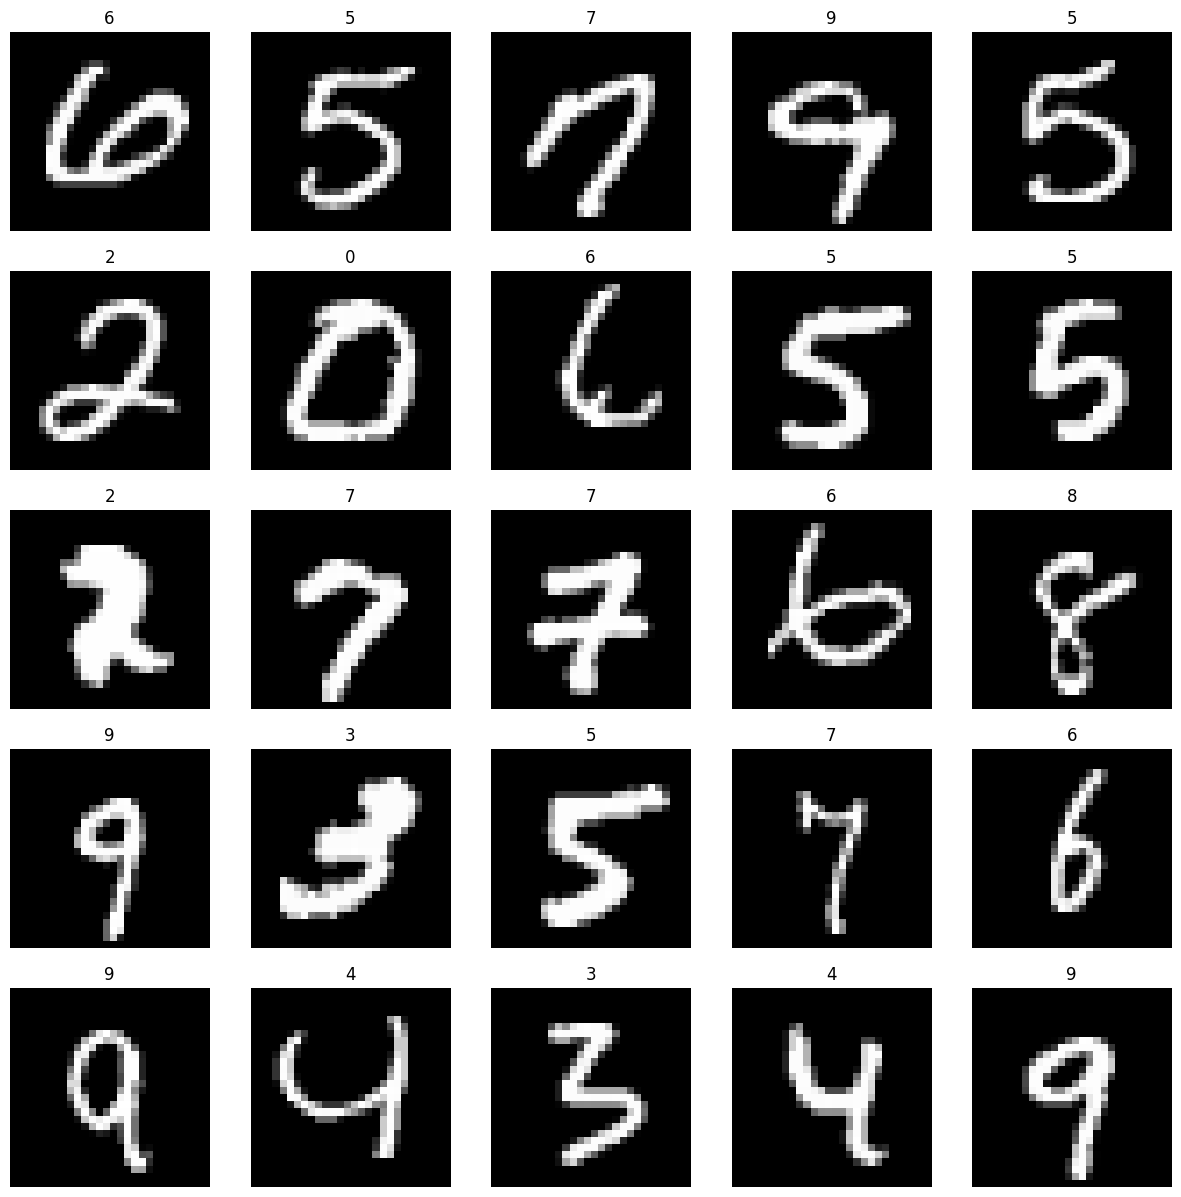

In [ ]:
# Visualize grid of samples
grid_size = (5,5)

_, axes = plt.subplots (grid_size[0] , grid_size[1] , figsize=(grid_size[1]*3, grid_size[0]*3)) #primero horizontal(col) y luego vertical(fila)
axes = axes.ravel() #ravel convierte un arreglo de cualquier dimension a una sola dimension

for i, ax in enumerate(axes):
  ax.imshow( X_train[i].reshape(28,28) , cmap='gray')# Reshape le digo que lea o interpreta la imagen
  ax.set_title(y_train[i]) #el titulo solo recibe string
  ax.set_axis_off()

In [ ]:
# Reshape the data - MLPs do not understand such '2D' stuff
# Reshape to 1D is similar to "flatten" an image

# Configuration options
feature_vector_length = 784
num_classes = 10

# Convert into 0 - 1 values and flatten
X_train = X_train.reshape(-1, feature_vector_length) / X_train.max()
X_val = X_val.reshape(-1, feature_vector_length) / X_val.max()
X_test = X_test.reshape(-1, feature_vector_length) / X_test.max()

In [ ]:
# Convert target classes to categorical ones - one hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("Shape of y_train after one-hot encoding:", y_train.shape)
print("Shape of y_test after one-hot encoding:", y_test.shape)

Shape of y_train after one-hot encoding: (16000, 10)
Shape of y_test after one-hot encoding: (10000, 10)


## Create a graph model

In [ ]:
#trabajar con la potencia de dos inferior al numero de entradas
model = nn.Sequential(
    nn.Linear( 784 , 512 ), nn.ReLU(), #linear anade una capa de perceptrones se pone una capa de entrada y el numero de perceptrones que se pone
    nn.Linear( 512 , 256 ), nn.ReLU(),
    nn.Linear( 256 , 128 ), nn.ReLU(),
    nn.Linear( 128 , 64 ), nn.ReLU(),
    nn.Linear( 64 , 32 ), nn.ReLU(),
    nn.Linear( 32 , num_classes ), nn.Softmax() #como salidas 10 perceptrones, es decir, 10 salidas lineales (el numero de clases)
)
from torchsummary import summary
summary(model, input_size=(784,), device='cpu')


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]         401,920
              ReLU-2                  [-1, 512]               0
            Linear-3                  [-1, 256]         131,328
              ReLU-4                  [-1, 256]               0
            Linear-5                  [-1, 128]          32,896
              ReLU-6                  [-1, 128]               0
            Linear-7                   [-1, 64]           8,256
              ReLU-8                   [-1, 64]               0
            Linear-9                   [-1, 32]           2,080
             ReLU-10                   [-1, 32]               0
           Linear-11                   [-1, 10]             330
          Softmax-12                   [-1, 10]               0
Total params: 576,810
Trainable params: 576,810
Non-trainable params: 0
-------------------------------

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1879: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return inner()


## Define loss function and optimizer

In [ ]:
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001 ) # Define the learning rate

## Train model

In [ ]:
# Model params for training
epochs = 100
batch_size = 200 # We dont train the whole dataset at the time
losses = []

progress = tqdm(range(epochs), ncols=110)

start_time = time.time()

print("Length of X_train at the start of the training loop:", len(X_train)) # Debugging print statement

for epoch in progress : # Iterate over all the num of epochs
  #
  # progress = _
  batch_losses = 0

  for batch_idx in range(0, len(X_train), batch_size): # Iterate over all batches of data
    #
    # First step, take the data from the dataset
    batch_X = X_train[batch_idx : batch_idx + batch_size]
    batch_y = y_train[batch_idx : batch_idx + batch_size]

    batch_X = torch.from_numpy(batch_X).to(torch.float32) # Convert to torch tensor to feed the graph
    batch_y = torch.from_numpy(batch_y).to(torch.float32) # Convert to torch tensor to feed the graph

    # Zero the gradients
    optimizer.zero_grad()

    # Perform forward pass
    predictions = model(batch_X)

    # Compute loss
    batch_loss = loss(predictions, batch_y)

    # Perform backward pass
    batch_loss.backward()

    # Optimize parameters
    optimizer.step()

    ## Accumulate loss to compute mean over all batches
    batch_losses += batch_loss.item()

    # Compute time and show all progress
    elapsed_time = time.time() - start_time
    progress.set_description("[Epoch %d/%d] [Loss: %f] [Elapsed Time: %f]" % (epoch + 1, epochs,
                                                            batch_losses / (len(X_train)/batch_size),
                                                            elapsed_time))

  # Save epoch loss
  losses.append(batch_losses/(len(X_train)/batch_size))

  0%|                                                                                 | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
[Epoch 1/100] [Loss: 0.005623] [Elapsed Time: 0.182986]:   0%|                        | 0/100 [00:00<?, ?it/s]

Length of X_train at the start of the training loop: 16000


[Epoch 100/100] [Loss: 0.000454] [Elapsed Time: 169.856264]: 100%|██████████| 100/100 [02:49<00:00,  1.70s/it]


## Plot results

Text(0.5, 1.0, 'Loss (MSE)')

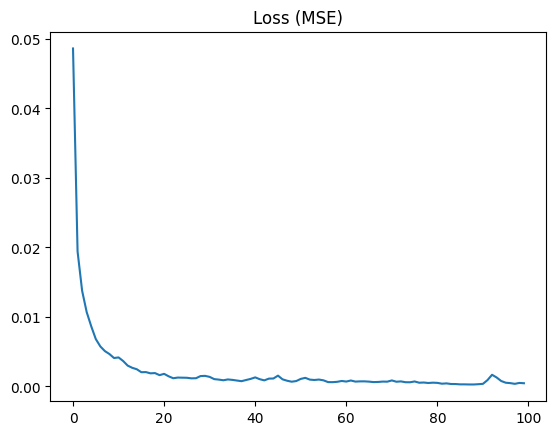

In [ ]:
# Plot progress (loss function)
plt.plot(losses)
plt.title("Loss (MSE)")

## Compute metrics over ```X_test``` images

100%|██████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 211.82it/s]


Shape of y_test before argmax: (10000, 10)
acc: 0.9629


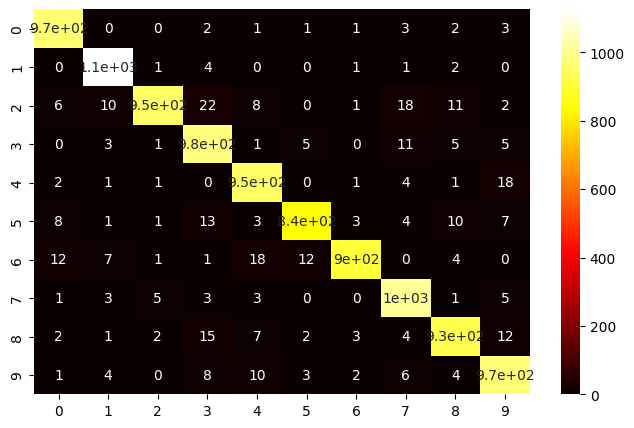

In [ ]:
progress = tqdm(range( 0 , len(X_test) , batch_size ), ncols=100)
predictions = []

for batch_idx in progress: # Iterate over all batches of data
  #
  batch_X = X_test[batch_idx : batch_idx + batch_size]
  # batch_y = y_test[batch_idx : batch_idx + batch_size] # No need to batch y_test here

  batch_X = torch.from_numpy(batch_X).to(torch.float32) # Convert to torch tensor to feed the graph
  # batch_y = torch.from_numpy(batch_y).to(torch.float32) # No need to convert y_test batch to tensor

  # Perform forward pass to compute predictions
  batch_predictions = model(batch_X)
  predictions.append(batch_predictions.detach().numpy())

predictions = np.concatenate(predictions, axis=0)
predictions = np.argmax(predictions, axis=1) #the predictions are of 10 dimensions

print("Shape of y_test before argmax:", y_test.shape) # Debugging print statement
y_test_ = np.argmax(y_test, axis=1)
acc = accuracy_score(y_test_, predictions)
cm = confusion_matrix(y_test_, predictions)

# Compute confusion matrix and accuracy
_, ax = plt.subplots(figsize=(8,5))
sns.heatmap(cm, cmap="hot", annot=True, ax=ax)
print("acc: {0}".format(acc))

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
